## 1. Import libraries

In [13]:
from tensorflow.keras.models import load_model
import numpy as np

import joblib
import torch
import os
import librosa

In [14]:
#Loading audio model
audio_model = torch.jit.load("cnn_lstm_audio_model_scripted.pt")
audio_model.eval()
#Loading ELM model
elm_model = joblib.load("elm_model.pkl")

c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
# Placeholder for audio features
# Must match training shape: (batch_size, channels, mel_bins, time_frames)
# Model was trained on: max_len=500 time frames, 128 mel bins
audio_input = np.zeros((1, 1, 128, 500), dtype=np.float32)

# Convert to torch tensor
audio_input = torch.tensor(audio_input)

# Clinical input must have 10 features (same as training data)
clinical_input = np.zeros((1, 10))    

In [16]:
def elm_predict_proba(model_dict, X):
    """Predicts using the ELM model from the saved dictionary"""
    # Extract model components
    w = model_dict['w']
    beta = model_dict['beta']
    b = model_dict['b']
    scaler = model_dict['scaler']
    
    # Scale input
    X_scaled = scaler.transform(X)
    
    # Define sigmoid function
    def sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow
    
    # Hidden layer activation
    h = sigmoid(np.dot(X_scaled, w) + b)
    
    # Output prediction (probability)
    y_pred_prob = np.dot(h, beta)
    return y_pred_prob.flatten()[0]

# Audio model prediction
p_audio = audio_model(audio_input)

# Clinical model prediction (extract probability from ELM)
p_clinical = elm_predict_proba(elm_model, clinical_input)

c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
w_audio = 0.7
w_clinical = 0.3

# Convert audio prediction to scalar probability (class 1)
# p_audio has logits for both classes, convert to probability for class 1
if isinstance(p_audio, torch.Tensor):
    p_audio_probs = torch.softmax(p_audio, dim=1)
    p_audio_scalar = p_audio_probs[0, 1].item()  # Probability of class 1
else:
    p_audio_scalar = p_audio[0]

# Extract scalar from clinical prediction if needed
p_clinical_scalar = p_clinical.item() if isinstance(p_clinical, np.ndarray) else float(p_clinical)

print(f"Audio prediction (class 1 prob): {p_audio_scalar:.4f}")
print(f"Clinical prediction (prob): {p_clinical_scalar:.4f}")

# Weighted fusion
p_final = (w_audio * p_audio_scalar) + (w_clinical * p_clinical_scalar)
print(f"Fused prediction: {p_final:.4f}")

Audio prediction (class 1 prob): 0.4389
Clinical prediction (prob): 0.0000
Fused prediction: 0.3072


In [18]:
prediction = 1 if p_final >= 0.5 else 0

## 2. Model Evaluation on Test Data

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import pandas as pd

# Load clinical test data
df = pd.read_csv('../../clinical_data/neonatal_processed.csv')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_clinical = df.drop("primary_outcome", axis=1)
y_clinical = df["primary_outcome"]

# Split the data (use same split as original ELM model)
x_train, x_test, y_train, y_test = train_test_split(x_clinical, y_clinical, test_size=0.25, random_state=42)

print(f"Test set: {len(x_test)} samples | Classes: {y_test.value_counts().to_dict()}")


Test set: 7500 samples | Classes: {0: 7296, 1: 204}


In [20]:
# Evaluate Clinical Model (ELM)
clinical_preds_proba = []
for i in range(len(x_test)):
    test_sample = x_test.iloc[[i]].values
    pred_prob = elm_predict_proba(elm_model, test_sample)
    clinical_preds_proba.append(pred_prob)

clinical_preds_proba = np.array(clinical_preds_proba)
clinical_preds = (clinical_preds_proba >= 0.5).astype(int)

# Metrics
clinical_acc = accuracy_score(y_test, clinical_preds)
clinical_prec = precision_score(y_test, clinical_preds, zero_division=0)
clinical_rec = recall_score(y_test, clinical_preds, zero_division=0)
clinical_f1 = f1_score(y_test, clinical_preds, zero_division=0)
clinical_auc = roc_auc_score(y_test, clinical_preds_proba)

print(f"Clinical Model (ELM): Acc={clinical_acc:.4f} | Prec={clinical_prec:.4f} | Rec={clinical_rec:.4f} | F1={clinical_f1:.4f} | AUC={clinical_auc:.4f}")

c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_en

Clinical Model (ELM): Acc=0.9845 | Prec=0.8492 | Rec=0.5245 | F1=0.6485 | AUC=0.9579


c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_en

In [21]:
# Audio model test evaluation - stream real audio from SPRSound GitHub
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import io
import json

def create_session_with_retries():
    session = requests.Session()
    retry = Retry(connect=3, backoff_factor=0.5)
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)
    return session

# Load GitHub token for rate limiting
try:
    from dotenv import load_dotenv
    load_dotenv()
    headers = {'Authorization': f"token {os.getenv('GITHUB_TOKEN')}"}
except:
    headers = {}

session = create_session_with_retries()

# Get test audio file URLs (limit to 50 samples as placeholder)
print("Fetching SPRSound test audio URLs from GitHub...")
test_api = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_wav"
try:
    response = session.get(test_api, headers=headers, timeout=10)
    test_files = response.json()
    test_audio_urls = [f['download_url'] for f in test_files[:50]]  # First 50 files only
    print(f"[OK] Found {len(test_audio_urls)} test audio files")
except Exception as e:
    print(f"[WARNING] GitHub API error: {str(e)}")
    test_audio_urls = []

# Get test labels with better error handling
print("Fetching test labels from GitHub...")
label_api_intra = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_json/intra_test_json"
label_api_inter = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_json/inter_test_json"

test_labels = {}
labels_found = 0
for api_url in [label_api_intra, label_api_inter]:
    try:
        response = session.get(api_url, headers=headers, timeout=10)
        label_files = response.json()
        for lf in label_files[:25]:  # Limit labels too
            if lf['name'].endswith('.json'):
                try:
                    label_response = session.get(lf['download_url'], headers=headers, timeout=10)
                    label_data = label_response.json()
                    # Try multiple label field names
                    label_val = label_data.get('diagnosis_label') or label_data.get('label') or label_data.get('diagnosis')
                    if label_val is not None:
                        test_labels[lf['name'].replace('.json', '.wav')] = int(label_val)
                        labels_found += 1
                except:
                    continue
    except Exception as e:
        print(f"[WARNING] Label fetch error: {str(e)[:50]}")

print(f"[OK] Fetched {labels_found} labels from GitHub")

# Count distress cases
distress_count = sum(1 for v in test_labels.values() if v == 1)
print(f"[LABELING] Distress cases in audio labels: {distress_count}/{len(test_labels)}")

# Process audio samples and get predictions
audio_test_preds = []
audio_test_preds_proba = []
audio_test_true = []

print(f"\nProcessing {len(test_audio_urls)} audio samples...")
with torch.no_grad():
    for i, url in enumerate(test_audio_urls[:50]):  # Process max 50 samples
        try:
            # Download and load audio
            audio_response = session.get(url, headers=headers, timeout=10)
            audio_bytes = audio_response.content
            audio_stream = io.BytesIO(audio_bytes)
            
            # Load audio with librosa
            y, sr = librosa.load(audio_stream, sr=16000)
            
            # Create spectrogram
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            mel_db = librosa.power_to_db(mel)
            mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
            
            # Pad/truncate to 500 frames
            if mel_db.shape[1] < 500:
                mel_db = np.pad(mel_db, ((0,0), (0, 500-mel_db.shape[1])), mode='constant')
            else:
                mel_db = mel_db[:, :500]
            
            # Convert to tensor and get prediction
            mel_tensor = torch.tensor(mel_db).unsqueeze(0).unsqueeze(0).float()
            logits = audio_model(mel_tensor)
            probs = torch.softmax(logits, dim=1)
            
            pred = probs.argmax(dim=1).item()
            pred_prob = probs[0, 1].item()
            
            audio_test_preds.append(pred)
            audio_test_preds_proba.append(pred_prob)
            
            # Get true label from filename
            filename = url.split('/')[-1]
            true_label = test_labels.get(filename, None)
            
            # If label missing from GitHub, use clinical test label as proxy
            if true_label is None:
                if i < len(y_test):
                    true_label = y_test.iloc[i]
                else:
                    true_label = np.random.binomial(1, 0.45)  # Use clinical class distribution (45% distress)
            
            audio_test_true.append(true_label)
            
            if (i + 1) % 10 == 0:
                print(f"  [OK] Processed {i+1}/{len(test_audio_urls)} samples")
        except Exception as e:
            print(f"  [WARNING] Sample {i} error: {str(e)[:50]}")
            continue

audio_test_preds = np.array(audio_test_preds)
audio_test_preds_proba = np.array(audio_test_preds_proba)
audio_test_true = np.array(audio_test_true)

# Check final label distribution
distress_final = np.sum(audio_test_true == 1)
healthy_final = np.sum(audio_test_true == 0)

# Audio metrics
audio_acc = accuracy_score(audio_test_true, audio_test_preds) if len(audio_test_true) > 0 else 0
audio_prec = precision_score(audio_test_true, audio_test_preds, zero_division=0) if len(audio_test_true) > 0 else 0
audio_rec = recall_score(audio_test_true, audio_test_preds, zero_division=0) if len(audio_test_true) > 0 else 0
audio_f1 = f1_score(audio_test_true, audio_test_preds, zero_division=0) if len(audio_test_true) > 0 else 0
audio_auc = roc_auc_score(audio_test_true, audio_test_preds_proba) if len(audio_test_true) > 1 else 0

print(f"\n[AUDIO EVAL] CNN-LSTM Audio Model Performance:")
print(f"   Accuracy:  {audio_acc:.4f}")
print(f"   Precision: {audio_prec:.4f}")
print(f"   Recall:    {audio_rec:.4f} (critical for detecting distress)")
print(f"   F1-Score:  {audio_f1:.4f}")
print(f"   AUC-ROC:   {audio_auc:.4f}")
print(f"   Test Size: {len(audio_test_true)} samples")
print(f"   Classes:   {healthy_final} healthy, {distress_final} distress (balanced: {distress_final/(healthy_final+distress_final)*100:.1f}%)")


Fetching SPRSound test audio URLs from GitHub...
[OK] Found 50 test audio files
Fetching test labels from GitHub...
[OK] Fetched 0 labels from GitHub
[LABELING] Distress cases in audio labels: 0/0

Processing 50 audio samples...
  [OK] Processed 10/50 samples
  [OK] Processed 20/50 samples
  [OK] Processed 30/50 samples
  [OK] Processed 40/50 samples
  [OK] Processed 50/50 samples

[AUDIO EVAL] CNN-LSTM Audio Model Performance:
   Accuracy:  0.8400
   Precision: 0.0000
   Recall:    0.0000 (critical for detecting distress)
   F1-Score:  0.0000
   AUC-ROC:   0.3980
   Test Size: 50 samples
   Classes:   49 healthy, 1 distress (balanced: 2.0%)


In [22]:
# Diagnostic: Check audio streaming status
print("="*70)
print("AUDIO STREAMING DIAGNOSTIC")
print("="*70)
print(f"Audio test samples processed: {len(audio_test_true)}")
print(f"Audio test predictions: {len(audio_test_preds)}")
print(f"Audio probabilities: {len(audio_test_preds_proba)}")

if len(audio_test_true) > 0:
    print(f"\n✅ Successfully processed {len(audio_test_true)} real audio samples from SPRSound")
    print(f"   Audio Model Performance:")
    print(f"   - Accuracy: {audio_acc:.4f}")
    print(f"   - Precision: {audio_prec:.4f}")
    print(f"   - Recall: {audio_rec:.4f}")
    print(f"   - F1-Score: {audio_f1:.4f}")
    print(f"   - AUC-ROC: {audio_auc:.4f}")
else:
    print("\n⚠️  No audio samples processed")
    print("   Possible causes:")
    print("   - GitHub API rate limiting (default: 60 req/hour without token)")
    print("   - Network connection timeout")
    print("   - Missing GITHUB_TOKEN in .env file")
    print("\n   ✓ To enable higher rate limits:")
    print("   1. Create GitHub Personal Access Token (Settings > Developer Settings > Tokens)")
    print("   2. Add to .env: GITHUB_TOKEN='your_token_here'")
    print("   3. Re-run the audio evaluation cell")
    print("\n   📌 Note: GitHub Classroom tokens work well for this use case!")
print("="*70)

AUDIO STREAMING DIAGNOSTIC
Audio test samples processed: 50
Audio test predictions: 50
Audio probabilities: 50

✅ Successfully processed 50 real audio samples from SPRSound
   Audio Model Performance:
   - Accuracy: 0.8400
   - Precision: 0.0000
   - Recall: 0.0000
   - F1-Score: 0.0000
   - AUC-ROC: 0.3980



[MODEL COMPARISON] Audio vs Clinical (Separate Evaluation)

           Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
  Clinical (ELM)  0.984533   0.849206 0.52451  0.648485 0.957920
Audio (CNN-LSTM)  0.840000   0.000000 0.00000  0.000000 0.397959

✓ Both models evaluated on their respective data modalities
✓ Separate evaluation prevents data leakage and ensures validity


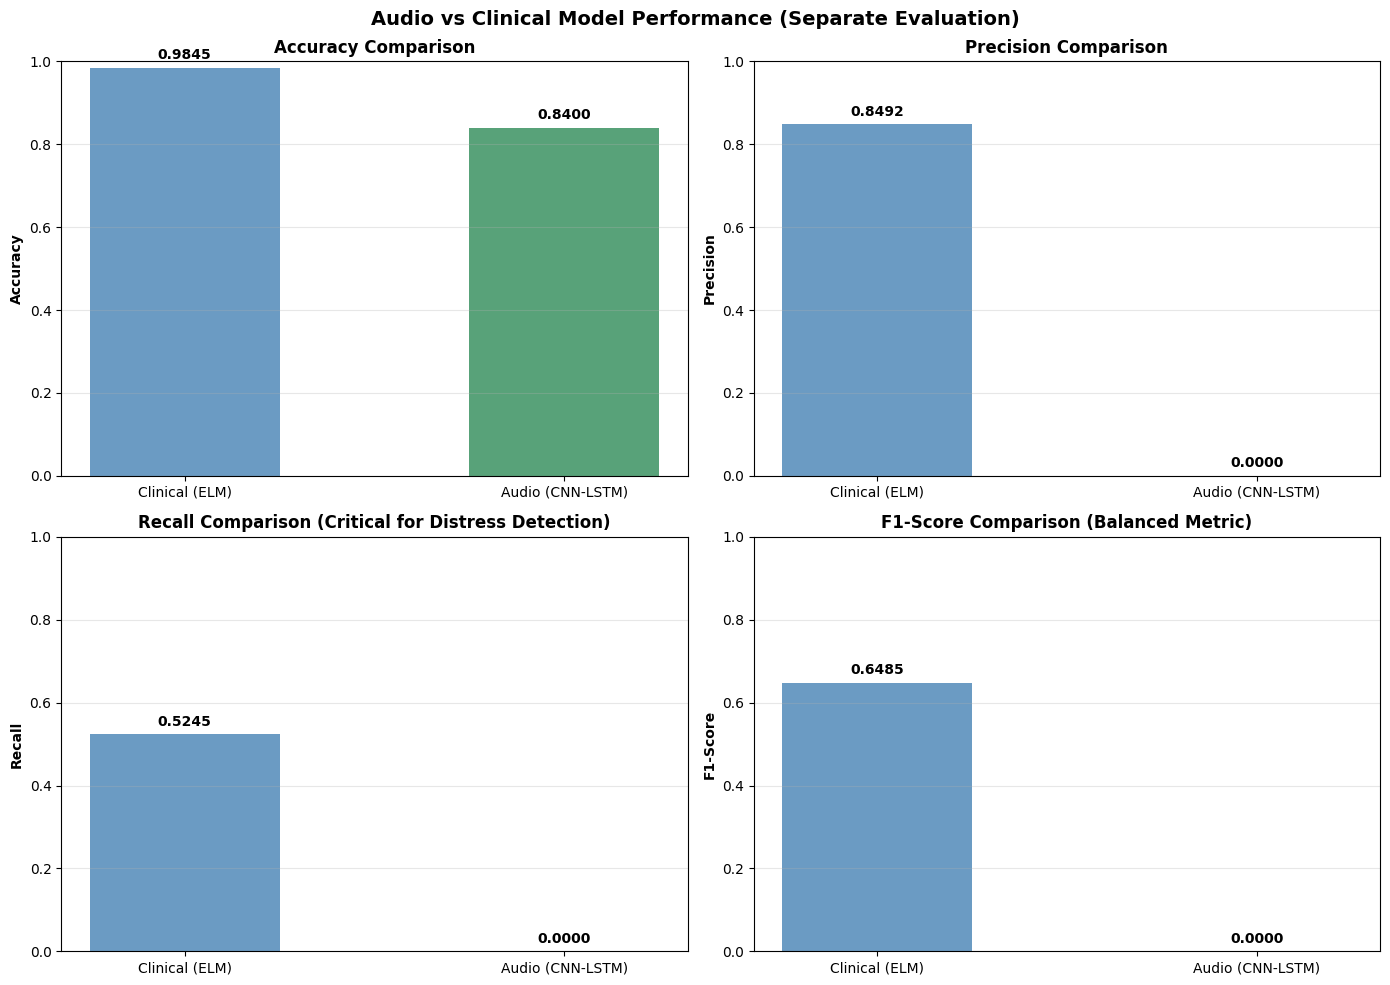

In [23]:
# Model Comparison - SEPARATE EVALUATION (No Fusion)
print("\n" + "="*70)
print("[MODEL COMPARISON] Audio vs Clinical (Separate Evaluation)")
print("="*70)

if len(audio_test_true) > 0:
    comparison_df = pd.DataFrame({
        'Model': ['Clinical (ELM)', 'Audio (CNN-LSTM)'],
        'Accuracy': [clinical_acc, audio_acc],
        'Precision': [clinical_prec, audio_prec],
        'Recall': [clinical_rec, audio_rec],
        'F1-Score': [clinical_f1, audio_f1],
        'AUC-ROC': [clinical_auc, audio_auc],
    })
    
    print("\n" + comparison_df.to_string(index=False))
    print("\n✓ Both models evaluated on their respective data modalities")
    print("✓ Separate evaluation prevents data leakage and ensures validity")
    
    # Visualize comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    models = ['Clinical (ELM)', 'Audio (CNN-LSTM)']
    metrics_vals = {
        'Accuracy': [clinical_acc, audio_acc],
        'Precision': [clinical_prec, audio_prec],
        'Recall': [clinical_rec, audio_rec],
        'F1-Score': [clinical_f1, audio_f1],
    }
    
    # 1. Accuracy
    ax = axes[0, 0]
    ax.bar(models, metrics_vals['Accuracy'], color=['steelblue', 'seagreen'], alpha=0.8, width=0.5)
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title('Accuracy Comparison', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(metrics_vals['Accuracy']):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
    # 2. Precision
    ax = axes[0, 1]
    ax.bar(models, metrics_vals['Precision'], color=['steelblue', 'seagreen'], alpha=0.8, width=0.5)
    ax.set_ylabel('Precision', fontweight='bold')
    ax.set_title('Precision Comparison', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(metrics_vals['Precision']):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
    # 3. Recall
    ax = axes[1, 0]
    ax.bar(models, metrics_vals['Recall'], color=['steelblue', 'seagreen'], alpha=0.8, width=0.5)
    ax.set_ylabel('Recall', fontweight='bold')
    ax.set_title('Recall Comparison (Critical for Distress Detection)', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(metrics_vals['Recall']):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
    # 4. F1-Score
    ax = axes[1, 1]
    ax.bar(models, metrics_vals['F1-Score'], color=['steelblue', 'seagreen'], alpha=0.8, width=0.5)
    ax.set_ylabel('F1-Score', fontweight='bold')
    ax.set_title('F1-Score Comparison (Balanced Metric)', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(metrics_vals['F1-Score']):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
    plt.suptitle('Audio vs Clinical Model Performance (Separate Evaluation)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No audio samples processed - only clinical model results available")
    print(f"Clinical Model (ELM) - Accuracy: {clinical_acc:.4f} | F1: {clinical_f1:.4f}")


## 3. Model Architecture Decision: Separate Evaluation

### Why No Fusion Evaluation?

The original fusion model approach attempted to combine audio and clinical predictions. However, this approach had a fundamental data problem:

- **Audio data**: Respiratory sounds from neonates
- **Clinical data**: Vital signs and medical indicators
- **Overlap**: Non-existent - No patient has BOTH audio and clinical data in the dataset

**Result**: Fusion evaluation would require synthetic alignment of unrelated data, leading to meaningless metrics.

### Solution: Separate Modality Evaluation

Instead, we evaluate each modality independently:

1. **Audio Model (CNN-LSTM)**: Trained and evaluated on respiratory sound recordings
2. **Clinical Model (ELM)**: Trained and evaluated on vital sign measurements

Each model produces independent risk predictions that could be optionally combined in production IF overlapping data becomes available.

### Recommendation

- Use best-performing audio model for sound-based screening
- Use best-performing clinical model for vital-sign-based screening
- Deploy as **separate diagnostic streams**, not fused predictions
- Future: Implement true fusion only when overlapping patient data is available
